# Ice streams, once more

In this demo, we'll revisit the ice stream scenario from before but with a different model.
The model that we'll use here can resolve both *plug flow* and *shear flow*.
The velocity is a plug flow if the velocity is roughly constanty with depth, whereas in shear flow the speed at the ice base is much smaller than at the ice surface.
Deep in the interior of an ice sheet, most flow is by vertical shear, whereas the fast ice streams near the margins are roughly in plug flow.
The shallow stream equations, and the `IceStream` class we used to solve them in the third demo, assume plug flow and thus are limited in the regions where they can be applied without substantial error.
The `HybridModel` class we'll use here has no such limitation.

### Geometry and input data

We'll use the same footprint geometry as the ice stream demo, but since we're working with a flowband instead of a flowline model, we'll need a mesh that resolves the $z$ direction as well as $x$.
The model we will use is posed entirely in *terrain-following coordinates*, where the $z$-axis is remapped into the interval $[0, 1]$.
This new coordinate is defined as

$$\zeta = \frac{z - b}{h}$$

and the inverse transformation is $z = h\zeta + b$.
In the absence of terminus advance or iceberg calving, the transformation to this coordinate system makes the logical geometry of problem completely steady even though the surface can be rising or falling.

Firedrake includes built-in support generating *extruded meshes* out of a footprint mesh.
Rather than use a large number of vertical layers to achieve high resolution of functions defined on this mesh, we'll use only one layer but high-degree basis functions.

In [1]:
import irksome
import firedrake
from icepack2.model import hybrid, mass_balance
from firedrake import dx
import matplotlib.pyplot as plt
from icepackaccs import extract_surface, extract_bed
import numpy as np
import icepack
from icepack.constants import (
    ice_density as ρ_I,
    water_density as ρ_W,
    weertman_sliding_law ,
    gravity as g,
    glen_flow_law,
)
import icepack.models.hybrid

Lx = 50e3
nx = 48 * 4
mesh1d = firedrake.IntervalMesh(nx, Lx)
mesh = firedrake.ExtrudedMesh(mesh1d, layers=1)

To define a function space on an extruded mesh, the only change over 1D function spaces is the addition of the `vfamily` and `vdegree` arguments.
These describe respectively the finite element type and polynomial degree in the vertical direction.
The surface and bed elevation only have to be defined on the footprint mesh, so we'll use vertical basis functions that are constant.

In [ ]:
Q = firedrake.FunctionSpace(
    mesh, "CG", 1, vfamily="R", vdegree=0
)
Δ = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="R", vdegree=0)

The function space for the velocities is more interesting.
Rather than use the usual continuous or discontinuous Galerkin finite element bases in the vertical, we'll use *Gauss-Legendre* elements.
This finite element uses [Legendre polynomials](https://en.wikipedia.org/wiki/Legendre_polynomials) instead of the Lagrange interpolating polynomials.
The Legendre polynomials are advantageous because they are mutually orthogonal.

In [ ]:
vdegree = 2
V = firedrake.FunctionSpace(mesh, "CG", 2, vfamily="GL", vdegree=vdegree)
Σx = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree - 1))
T1 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree - 1))
T0 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="R", vdegree=0)
Z = V * Σx * T1 * T0

In [ ]:
V2 = firedrake.FunctionSpace(mesh, "CG", 2, vfamily="GL", vdegree=vdegree * 2)
Σx2 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree * 2 - 1))
T2 = firedrake.FunctionSpace(mesh, "DG", 1, vfamily="GL", vdegree=max(0, vdegree * 2 - 1))
Z2 = V2 * Σx2 * T2 * T0

Creating the input data is mostly the same as before.
The `SpatialCoordinate` function now returns an additional symbol representing the terrain-following coordinate $\zeta$.

In [6]:
m = firedrake.Constant(weertman_sliding_law)
n = firedrake.Constant(glen_flow_law)
x, ζ = firedrake.SpatialCoordinate(mesh)

In [7]:
b_in, b_out = 500, 0
b = firedrake.Function(Q).interpolate(b_in - (b_in - b_out) * x / Lx)

s_in, s_out = 1000, 50
s0 = firedrake.Function(Δ).interpolate(s_in - (s_in - s_out) * (1 - ((Lx - x) / Lx) ** 0.5))


h0 = firedrake.Function(Δ).interpolate(s0 - b)
h = h0.copy(deepcopy=True)

s0 = icepack.compute_surface(thickness=h, bed=b)
s = s0.copy(deepcopy=True)

In [8]:
h_in = s_in - b_in
δs_δx = (s_out - s_in) / Lx
τ_D = -ρ_I * g * h_in * δs_δx

In [9]:
u_in, u_out = 0, 10
velocity_x = u_in + (u_out - u_in) * (x / Lx)**2
u0 = firedrake.Function(V).interpolate(velocity_x)

In [10]:
T = firedrake.Constant(268.0)
A = icepack.rate_factor(T)

In [11]:
area = firedrake.assemble(firedrake.Constant(1) * dx(mesh))
u_c = firedrake.assemble(firedrake.sqrt(firedrake.inner(u0, u0)) * dx(mesh)) / area
τ_c = firedrake.assemble(firedrake.sqrt(firedrake.inner(τ_D, τ_D)) * dx(mesh)) / area
ε_c = firedrake.Constant(A * τ_c ** n)

C = firedrake.Function(Q).interpolate((1 - 0.9 * x/Lx) * 0.25)

K = firedrake.Function(Q).interpolate(C ** (-m) * τ_c ** m).copy(deepcopy=True)

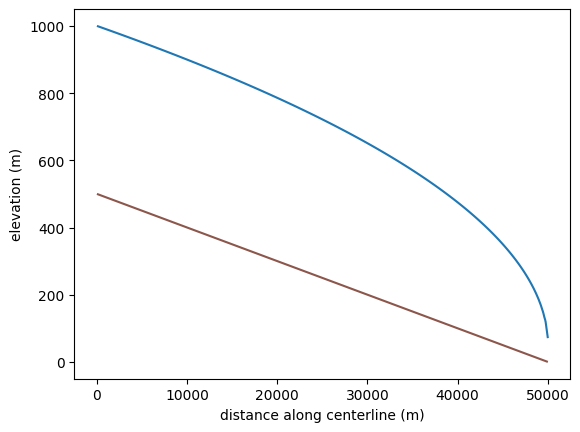

In [12]:
fig, axes = plt.subplots()
axes.set_xlabel("distance along centerline (m)")
axes.set_ylabel("elevation (m)")
firedrake.plot(
    icepack.depth_average(b), edgecolor="tab:brown", axes=axes
)
z_b = firedrake.Function(Q).interpolate(s - h)
firedrake.plot(
    extract_surface(s), edgecolor="tab:blue", axes=axes
);

In [13]:
z = firedrake.Function(Z)
z.sub(0).assign(u0)

u, Mx, Mz, τ = firedrake.split(z)
fields = {
    "velocity": u,
    "membrane_stress_x": Mx,
    "membrane_stress_z": Mz,
    "basal_stress": τ,
    "thickness": h,
    "surface": s,
    "outflow_ids": 2
}
rheology = {
    "flow_law_exponent": n,
    "flow_law_coefficient": ε_c / τ_c**n,
    "sliding_exponent": m,
    "sliding_coefficient": K / τ_c**m,
}

L = hybrid.HybridModel().action(**fields, **rheology)
F = firedrake.derivative(L, z)

In [14]:
inflow_ids = [1]
bc_in = firedrake.DirichletBC(Z.sub(0), u0, inflow_ids)
bcs = [bc_in]

qdegree = int(max(glen_flow_law, weertman_sliding_law)) + 2
problem_params = {
    "form_compiler_parameters": {"quadrature_degree": qdegree},
    "bcs": bcs,
}
solver_params = {
    "solver_parameters": {
        #"snes_linesearch_monitor": None,
        #"snes_converged_reason": None,
        #"ksp_monitor": None,
        #"ksp_view": None,
        "snes_stol": 0.0,
        "snes_rtol": 0.0,
        "snes_atol": 1.0e-4,
        "snes_max_it": 250,
        "snes_divergence_tolerance": -1,
        "snes_type": "newtonls",
        "snes_linesearch_type": "nleqerr",
        "ksp_type": "gmres",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "umfpack",
    },
}
# solver_params["solver_parameters"]["snes_monitor"] = None
# solver_params["solver_parameters"]["ksp_monitor"] = None
# firedrake.solve(F_1 == 0, z, **problem_params, **solver_params)

u_problem = firedrake.NonlinearVariationalProblem(F, z, **problem_params)  # may need to add J=J here
u_solver = firedrake.NonlinearVariationalSolver(u_problem, **solver_params)

In [15]:
rheology_steps = 5
ms = np.linspace(1.0, weertman_sliding_law, rheology_steps)
# ms = weertman_sliding_law * np.ones_like(ms)
ns = np.linspace(1.0, glen_flow_law, rheology_steps)

In [16]:
for rheo_step in range(rheology_steps):
    m.assign(ms[rheo_step])
    n.assign(ns[rheo_step])
    u_solver.solve()

The bed friction can be re-parameterized for the hybrid model in the same way as for the ice stream model.

In [17]:
def friction(**kwargs):
    u = kwargs["velocity"]
    C = kwargs["friction"]

    return icepack.models.hybrid.bed_friction(
        velocity=u,
        friction=C,
    )

def friction_stress(**kwargs):
    u = kwargs["velocity"]
    C = kwargs["friction"]

    return -C * firedrake.sqrt(firedrake.inner(u, u)) ** (1 / 3 - 1) * u

The setup is the same as in the ice stream case, only here we're using `HybridModel` instead of `IceStream`.
Creating a `FlowSolver` works exactly the same as it did before no matter what model we're using.

In [18]:
model = icepack.models.HybridModel(friction=friction)
opts = {"dirichlet_ids": [1],
        "snes_stol": 0.0,
        "snes_rtol": 0.0,
        "snes_atol": 1.0e-4,
        "snes_max_it": 250,
        "snes_divergence_tolerance": -1,}
solver = icepack.solvers.FlowSolver(model, **opts)

u_primal_0 = solver.diagnostic_solve(
    velocity=u0,
    thickness=h,
    surface=s0,
    fluidity=A,
    friction=C,
)

One of the major differences between working with flowline and flowband models is that the fields are posed on different geometries and so the kinds of plots we can make are different.
Firedrake can make contour plots of flowband fields, but often we only care about changes in the horizontal dimension.
The function `depth_average` will integrate a flowband field with respect to $\zeta$ and give us back the corresponding 1D function, which we can then make line plots of.
(At the end of this demo we'll show how to make plots of the vertical variability.)

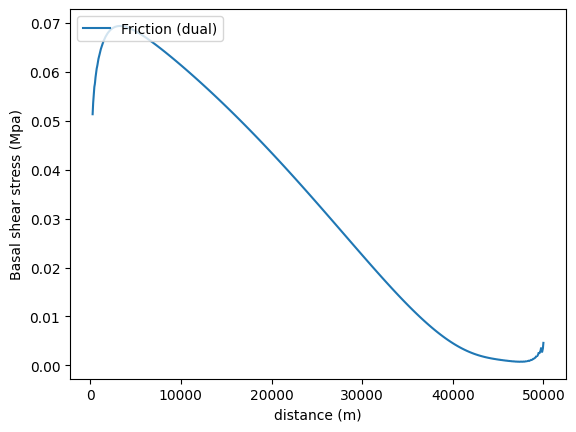

In [19]:
fig, axes = plt.subplots()
# axes.set_yscale("log")
axes.set_xlabel("distance (m)")
axes.set_ylabel("Basal shear stress (Mpa)")
#firedrake.plot(extract_bed(firedrake.Function(T0).interpolate(-τ)), axes=axes, label="Friction (dual)");
#firedrake.plot(extract_bed(firedrake.Function(V).interpolate(-friction_stress(velocity=u_primal_0, friction=C))), axes=axes, label="Friction (primal)");
#firedrake.plot(extract_bed(firedrake.Function(V).interpolate(-friction_stress(velocity=u, friction=C))), axes=axes, label="Friction (dual via primal)");
firedrake.plot(extract_bed(firedrake.Function(V).interpolate(firedrake.Function(V).interpolate(τ) - friction_stress(velocity=u_primal_0, friction=C))), axes=axes, label="Friction (dual)")

# axes.set_ylim(10, 2000)
plt.legend(loc="upper left")

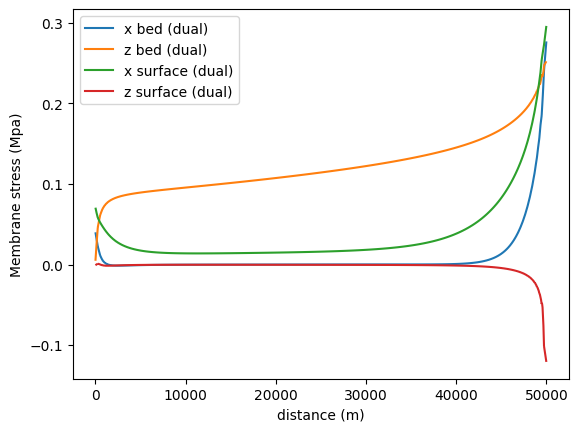

In [20]:
ex_primal = firedrake.Function(Σx).interpolate(hybrid.horizontal_strain_rate(velocity=u, thickness=h, surface=s))
ez_primal = firedrake.Function(Σx).interpolate(hybrid.vertical_strain_rate(velocity=u, thickness=h, surface=s))
cnorm = (firedrake.inner(ex_primal, ex_primal) + firedrake.inner(ez_primal, ez_primal)) / 2

Mx_primal = firedrake.Function(Σx).interpolate(2.0 * firedrake.Function(Q).interpolate(ε_c / τ_c**n) ** (1 / n) * (cnorm) ** (1/ n - 1) * (ex_primal))
Mz_primal = firedrake.Function(Σx).interpolate(2.0 * firedrake.Function(Q).interpolate(ε_c / τ_c**n) ** (1 / n) * (cnorm) ** (1/ n - 1) * (ez_primal / 2))

fig, axes = plt.subplots()
# axes.set_yscale("log")
axes.set_xlabel("distance (m)")
axes.set_ylabel("Membrane stress (Mpa)")
firedrake.plot(extract_bed(Mx), axes=axes, label="x bed (dual)");
firedrake.plot(extract_bed(Mz), axes=axes, label="z bed (dual)");
firedrake.plot(extract_surface(Mx), axes=axes, label="x surface (dual)");
firedrake.plot(extract_surface(Mz), axes=axes, label="z surface (dual)");
# firedrake.plot(extract_bed(Mx_primal), axes=axes, label="x bed (primal)");
#firedrake.plot(extract_bed(Mz_primal), axes=axes, label="z bed (primal)");
#firedrake.plot(extract_surface(Mx_primal), axes=axes, label="x surface (primal)");
#firedrake.plot(extract_surface(Mz_primal), axes=axes, label="z surface (primal)");
# axes.set_ylim(10, 2000)
plt.legend(loc="upper left")

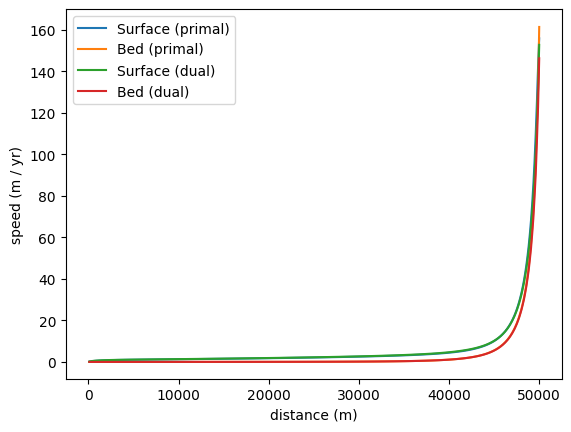

In [21]:
fig, axes = plt.subplots()
# axes.set_yscale("log")
axes.set_xlabel("distance (m)")
axes.set_ylabel("speed (m / yr)")
firedrake.plot(extract_surface(u_primal_0), axes=axes, label="Surface (primal)");
firedrake.plot(extract_bed(u_primal_0), axes=axes, label="Bed (primal)");
firedrake.plot(extract_surface(u), axes=axes, label="Surface (dual)");
firedrake.plot(extract_bed(u), axes=axes, label="Bed (dual)");
# axes.set_ylim(0.1, 100)
plt.legend(loc="upper left")

### Modeling

The code to run the hybrid model is identical to that of the ice stream demo.

In [22]:
from tqdm.notebook import trange

num_years = 100
timesteps_per_year = 10

dt = 1.0 / timesteps_per_year
num_timesteps = num_years * timesteps_per_year

a_0 = firedrake.Constant(1)
δa = firedrake.Constant(2)
a = firedrake.Function(Q).interpolate(a_0 - δa * x / Lx)

u_primal = u_primal_0.copy(deepcopy=True)

prognostic_problem = mass_balance(
    thickness=h,
    velocity=u,
    accumulation=a,
    thickness_inflow=h0,
    test_function=firedrake.TestFunction(Q),
)
t = firedrake.Constant(0.0)
method = irksome.BackwardEuler()
prognostic_params = {
    "solver_parameters": {
        "snes_type": "ksponly",
        "ksp_type": "gmres",
        "pc_type": "bjacobi",
    },
}
h_solver = irksome.TimeStepper(
    prognostic_problem, method, t, dt, h, **prognostic_params
)

for step in trange(num_timesteps):
    h_solver.advance()
    s.interpolate(icepack.compute_surface(thickness=h, bed=b))
    u_solver.solve()

  0%|          | 0/1000 [00:00<?, ?it/s]

As a sanity check, we can plot the thickness, velocity, and mass balance.
These give very similar results in the eyeball norm to our previous demo assuming only plug flow.
Note again that there are some wiggles on the upstream boundary.
This is the expected rapid adjustment of the ice within a few kilometers of the upstream boundary when the system isn't quite in equilibrium with the inflow values.
In a later notebook, we'll show how to relax the inflow values to equilibrate the two.

We're calling the `depth_average` function on the ice thickness below, which might seem a little weird.
Again, this is just a trick to get the thickness field, which is strictly defined on the mesh of the whole domain in x and z, onto the 1D footprint mesh.

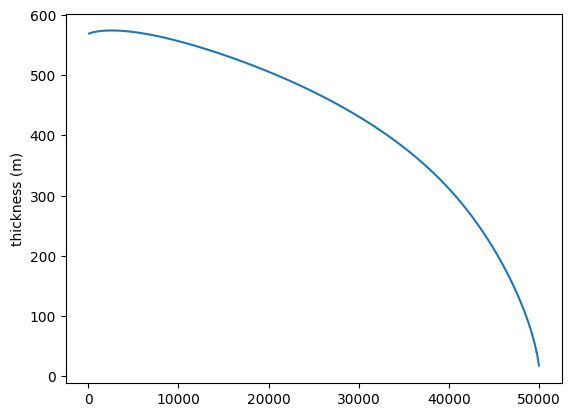

In [23]:
fig, axes = plt.subplots()
axes.set_ylabel("thickness (m)")
firedrake.plot(icepack.depth_average(h), axes=axes);

In [24]:
u_primal = solver.diagnostic_solve(
    velocity=u,
    thickness=h,
    surface=s,
    fluidity=A,
    friction=C,
)

The velocity profile again reproduces the gradual rise to a high value attained on the ice shelf.

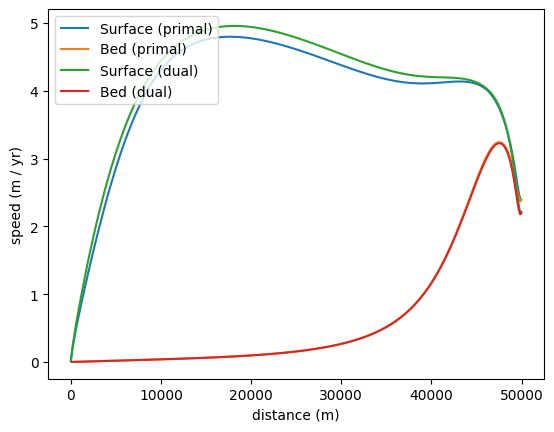

In [25]:
fig, axes = plt.subplots()
axes.set_xlabel("distance (m)")
axes.set_ylabel("speed (m / yr)")
firedrake.plot(extract_surface(u_primal), axes=axes, label="Surface (primal)");
firedrake.plot(extract_bed(u_primal), axes=axes, label="Bed (primal)");
firedrake.plot(extract_surface(u), axes=axes, label="Surface (dual)");
firedrake.plot(extract_bed(u), axes=axes, label="Bed (dual)");
plt.legend(loc="upper left")

Next, we'd like to plot the total mass balance, which in this case is

$$f = a - \frac{\partial}{\partial x}(hu).$$

Again, there are some oscillations upstream of the grounding line, but the overall magnitude is much smaller than when we started the simulation.

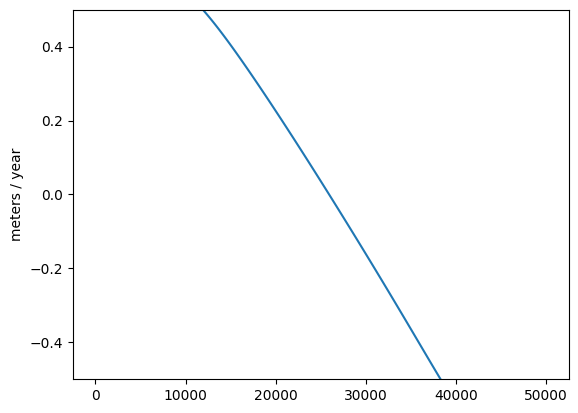

In [26]:
f = icepack.depth_average(firedrake.Function(Q).project(a - (h * u_primal).dx(0)))
fig, axes = plt.subplots()
axes.set_ylim(-0.5, +0.5)
axes.set_ylabel("meters / year")
colors = firedrake.plot(f, axes=axes);

To put everything together, we'll plot the geometry of the equilibrated ice stream, with the bed in brown and the ice base and surface in blue.
The results are again very similar to that of the ice stream case.

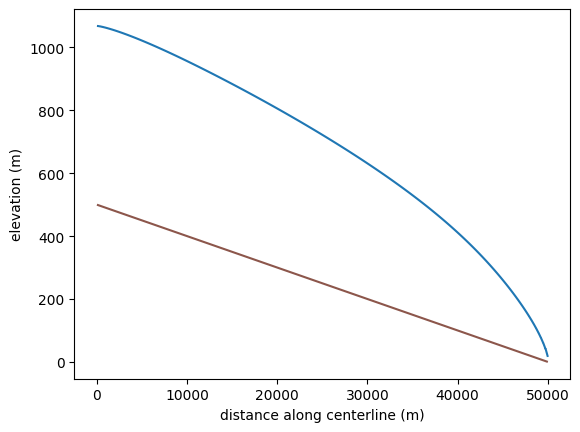

In [27]:
fig, axes = plt.subplots()
axes.set_xlabel("distance along centerline (m)")
axes.set_ylabel("elevation (m)")
firedrake.plot(
    icepack.depth_average(b), edgecolor="tab:brown", axes=axes
)
z_b = firedrake.Function(Q).interpolate(s - h)
firedrake.plot(
    icepack.depth_average(s), edgecolor="tab:blue", axes=axes
);